In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
TABLES_DIR = Path("tables")
FIGURES_DIR = Path("figures")

TABLES_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

In [3]:
df = pd.read_csv("saudi_data_jobs_cleaned.csv")

df.head()

,job_id,job_title,company,city,role_type,experience_level,skills,tools,source,job_link,date_collected,notes,city_cleaned,experience_category,role_category
0,1,Data Analyst,ALESAYI HOLDING,Jeddah,Data Analyst,Entry level / 3 years,"customer data analysis, operational performanc...","Excel, PowerPoint, dashboards",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Customer experience data analyst role in autom...,Jeddah,Entry Level,Data Analysis
1,2,Geological Data Scientist,Maaden Barrick Copper Company,Mahd Adh Dhahab,Data Scientist,Entry level / 2-5 years,"geological data management, data quality manag...","SQL, Python, Power BI, Tableau, relational dat...",LinkedIn,https://sa.linkedin.com/jobs/view/geological-d...,2026-06-30,Mining sector data science role. Focuses on ge...,Mahd Adh Dhahab,Entry Level,Data Science
2,3,Data Analyst,PrimeGate for Communications and IT,Riyadh,Data Analyst,Entry level,"data analysis, insights generation, dashboardi...","SQL, Power BI, Tableau, Looker, Excel, Python,...",LinkedIn,https://sa.linkedin.com/jobs/view/data-analyst...,2026-06-30,Entry-level data analyst role for Madinaty Sup...,Riyadh,Entry Level,Data Analysis
3,4,Analyst Pricing Analytics and Insights,Schneider Electric,Saudi Arabia,Business / Pricing Analytics,Entry level,"pricing analytics, data analysis, data interpr...","data visualization, dashboards, charts, reports",LinkedIn,https://sa.linkedin.com/jobs/view/analyst-pric...,2026-06-30,Entry-level pricing analytics role. Focuses on...,Not specified,Entry Level,Business / Financial Analytics
4,5,Power BI Developer,Acuative Middle East,Jeddah,BI / Power BI Developer,Mid-level,"Power BI dashboard development, business intel...","Power BI Desktop, Power BI Service, DAX, Power...",LinkedIn,https://sa.linkedin.com/jobs/view/power-bi-dev...,2026-06-30,Mid-level Power BI Developer role in Jeddah. F...,Jeddah,Not Specified,BI


In [4]:
df.shape

(45, 15)

In [5]:
df.columns

Index(['job_id', 'job_title', 'company', 'city', 'role_type',
       'experience_level', 'skills', 'tools', 'source', 'job_link',
       'date_collected', 'notes', 'city_cleaned', 'experience_category',
       'role_category'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               45 non-null     int64 
 1   job_title            45 non-null     object
 2   company              45 non-null     object
 3   city                 45 non-null     object
 4   role_type            45 non-null     object
 5   experience_level     45 non-null     object
 6   skills               45 non-null     object
 7   tools                45 non-null     object
 8   source               45 non-null     object
 9   job_link             45 non-null     object
 10  date_collected       45 non-null     object
 11  notes                45 non-null     object
 12  city_cleaned         45 non-null     object
 13  experience_category  45 non-null     object
 14  role_category        45 non-null     object
dtypes: int64(1), object(14)
memory usage: 5.4+ KB


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate job IDs:", df["job_id"].duplicated().sum())
print("Duplicate job links:", df["job_link"].duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

Rows: 45
Columns: 15
Duplicate rows: 0
Duplicate job IDs: 0
Duplicate job links: 0

Missing values:
job_id                 0
job_title              0
company                0
city                   0
role_type              0
experience_level       0
skills                 0
tools                  0
source                 0
job_link               0
date_collected         0
notes                  0
city_cleaned           0
experience_category    0
role_category          0
dtype: int64


In [9]:
tools_long = df.copy()

tools_long["tools"] = tools_long["tools"].fillna("")
tools_long["tool"] = tools_long["tools"].str.split(",")

tools_long = tools_long.explode("tool")

tools_long["tool"] = tools_long["tool"].astype(str).str.strip()

tools_long = tools_long[tools_long["tool"] != ""].copy()

tools_long[["job_id", "job_title", "tool"]].head(20)

,job_id,job_title,tool
0,1,Data Analyst,Excel
0,1,Data Analyst,PowerPoint
0,1,Data Analyst,dashboards
1,2,Geological Data Scientist,SQL
1,2,Geological Data Scientist,Python
1,2,Geological Data Scientist,Power BI
1,2,Geological Data Scientist,Tableau
1,2,Geological Data Scientist,relational databases
1,2,Geological Data Scientist,Acquire
1,2,Geological Data Scientist,DataShed


In [10]:
def normalize_tool(tool):
    tool = str(tool).strip()
    tool_lower = tool.lower()

    if tool_lower in ["power bi", "power bi desktop", "power bi service", "microsoft power bi"]:
        return "Power BI"

    elif tool_lower in ["tableau", "tableau desktop", "tableau server"]:
        return "Tableau"

    elif tool_lower in ["excel", "microsoft excel", "advanced excel", "pivot tables", "power pivot"]:
        return "Excel"

    elif tool_lower in ["sql", "sql queries", "advanced sql", "t-sql", "pl/sql"]:
        return "SQL"

    elif tool_lower in ["python", "python scripting", "python programming"]:
        return "Python"

    elif tool_lower == "r":
        return "R"

    elif tool_lower == "pandas":
        return "Pandas"

    elif tool_lower == "numpy":
        return "NumPy"

    elif tool_lower == "matplotlib":
        return "Matplotlib"

    elif tool_lower == "plotly":
        return "Plotly"

    elif tool_lower in ["powerpoint", "microsoft powerpoint"]:
        return "PowerPoint"

    elif tool_lower == "google sheets":
        return "Google Sheets"

    elif tool_lower in ["looker", "looker studio"]:
        return "Looker Studio"

    elif tool_lower in ["dashboards", "dashboard", "reporting dashboards"]:
        return "Dashboards"

    elif tool_lower in ["bi tools", "business intelligence tools", "reporting tools", "reporting platforms"]:
        return "BI / Reporting Tools"

    elif tool_lower == "tensorflow":
        return "TensorFlow"

    elif tool_lower == "pytorch":
        return "PyTorch"

    elif tool_lower in ["scikit-learn", "sklearn"]:
        return "Scikit-learn"

    elif tool_lower in ["machine learning", "machine learning tools", "machine learning frameworks"]:
        return "Machine Learning Tools"

    elif tool_lower in ["azure", "microsoft azure", "azure data factory", "azure synapse"]:
        return "Azure"

    elif tool_lower in ["aws", "aws redshift"]:
        return "AWS"

    elif tool_lower == "snowflake":
        return "Snowflake"

    elif tool_lower == "databricks":
        return "Databricks"

    elif tool_lower in ["alteryx", "alteryx designer"]:
        return "Alteryx"

    elif tool_lower == "ssis":
        return "SSIS"

    elif tool_lower == "grafana":
        return "Grafana"

    elif tool_lower == "sas":
        return "SAS"

    elif tool_lower in ["git", "git-based version control"]:
        return "Git"

    else:
        return tool


tools_long["tool_normalized"] = tools_long["tool"].apply(normalize_tool)

tools_long[["tool", "tool_normalized"]].head(30)

,tool,tool_normalized
0,Excel,Excel
0,PowerPoint,PowerPoint
0,dashboards,Dashboards
1,SQL,SQL
1,Python,Python
1,Power BI,Power BI
1,Tableau,Tableau
1,relational databases,relational databases
1,Acquire,Acquire
1,DataShed,DataShed


In [11]:
top_tools = tools_long["tool_normalized"].value_counts().reset_index()

top_tools.columns = ["tool", "count"]

top_tools.head(20)

,tool,count
0,SQL,24
1,Excel,21
2,Python,18
3,Power BI,18
4,Dashboards,14
5,Tableau,14
6,BI / Reporting Tools,14
7,TensorFlow,5
8,Machine Learning Tools,5
9,PyTorch,5


In [12]:
top_tools.to_csv(TABLES_DIR / "expanded_top_tools.csv", index=False)

print("expanded_top_tools.csv saved.")

expanded_top_tools.csv saved.


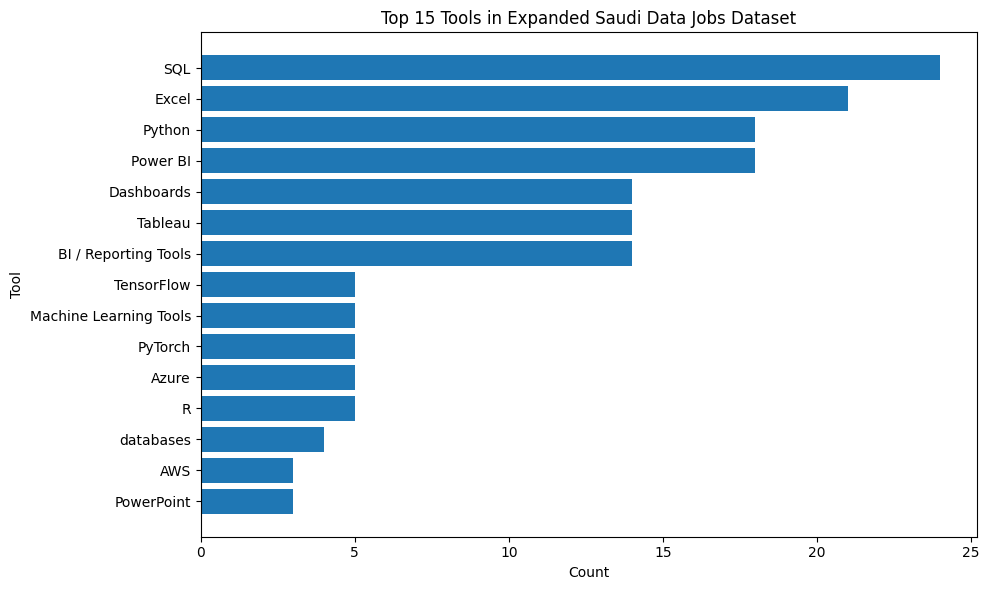

In [13]:
top_15_tools = top_tools.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15_tools["tool"], top_15_tools["count"])
plt.xlabel("Count")
plt.ylabel("Tool")
plt.title("Top 15 Tools in Expanded Saudi Data Jobs Dataset")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "expanded_top_15_tools.png", dpi=300, bbox_inches="tight")

plt.show()

In [14]:
skills_long = df.copy()

skills_long["skills"] = skills_long["skills"].fillna("")
skills_long["skill"] = skills_long["skills"].str.split(",")

skills_long = skills_long.explode("skill")

skills_long["skill"] = skills_long["skill"].astype(str).str.strip()

skills_long = skills_long[skills_long["skill"] != ""].copy()

skills_long[["job_id", "job_title", "skill"]].head(20)

,job_id,job_title,skill
0,1,Data Analyst,customer data analysis
0,1,Data Analyst,operational performance analysis
0,1,Data Analyst,data accuracy
0,1,Data Analyst,reporting
0,1,Data Analyst,dashboarding
0,1,Data Analyst,customer experience analysis
0,1,Data Analyst,complaint monitoring
0,1,Data Analyst,campaign performance tracking
0,1,Data Analyst,business insights
1,2,Geological Data Scientist,geological data management


In [15]:
def normalize_skill(skill):
    skill = str(skill).strip()
    skill_lower = skill.lower()

    if "data analysis" in skill_lower or "dataset analysis" in skill_lower:
        return "Data Analysis"

    elif "report" in skill_lower or "reporting" in skill_lower:
        return "Reporting"

    elif "dashboard" in skill_lower:
        return "Dashboarding"

    elif "data visualization" in skill_lower or "visualization" in skill_lower:
        return "Data Visualization"

    elif "data cleaning" in skill_lower or "data cleansing" in skill_lower:
        return "Data Cleaning"

    elif "data validation" in skill_lower or "data accuracy" in skill_lower or "data integrity" in skill_lower:
        return "Data Validation"

    elif "data quality" in skill_lower:
        return "Data Quality"

    elif "data governance" in skill_lower:
        return "Data Governance"

    elif "kpi" in skill_lower or "performance metric" in skill_lower or "scorecard" in skill_lower:
        return "KPI Tracking"

    elif "trend" in skill_lower or "pattern" in skill_lower:
        return "Trend / Pattern Analysis"

    elif "forecast" in skill_lower or "predictive" in skill_lower:
        return "Forecasting / Predictive Analytics"

    elif "machine learning" in skill_lower or "ml model" in skill_lower or "model development" in skill_lower:
        return "Machine Learning"

    elif "ai" in skill_lower or "generative ai" in skill_lower or "llm" in skill_lower:
        return "AI"

    elif "statistical" in skill_lower or "statistics" in skill_lower:
        return "Statistical Analysis"

    elif "stakeholder" in skill_lower or "communication" in skill_lower:
        return "Communication / Stakeholder Management"

    elif "problem solving" in skill_lower:
        return "Problem Solving"

    elif "business insight" in skill_lower or "actionable insight" in skill_lower or "insights generation" in skill_lower:
        return "Business Insights"

    elif "etl" in skill_lower or "data integration" in skill_lower:
        return "ETL / Data Integration"

    elif "fraud" in skill_lower:
        return "Fraud Analytics"

    elif "risk" in skill_lower:
        return "Risk Analysis"

    elif "reconciliation" in skill_lower:
        return "Data Reconciliation"

    elif "documentation" in skill_lower:
        return "Documentation"

    else:
        return skill


skills_long["skill_normalized"] = skills_long["skill"].apply(normalize_skill)

skills_long[["skill", "skill_normalized"]].head(30)

,skill,skill_normalized
0,customer data analysis,Data Analysis
0,operational performance analysis,operational performance analysis
0,data accuracy,Data Validation
0,reporting,Reporting
0,dashboarding,Dashboarding
0,customer experience analysis,customer experience analysis
0,complaint monitoring,AI
0,campaign performance tracking,AI
0,business insights,Business Insights
1,geological data management,geological data management


In [16]:
top_skills = skills_long["skill_normalized"].value_counts().reset_index()

top_skills.columns = ["skill", "count"]

top_skills.head(20)

,skill,count
0,Reporting,55
1,AI,41
2,Data Analysis,32
3,Data Validation,31
4,Trend / Pattern Analysis,26
5,Communication / Stakeholder Management,24
6,Dashboarding,23
7,Data Quality,19
8,KPI Tracking,18
9,Problem Solving,13


In [17]:
top_skills.to_csv(TABLES_DIR / "expanded_top_skills.csv", index=False)

print("expanded_top_skills.csv saved.")

expanded_top_skills.csv saved.


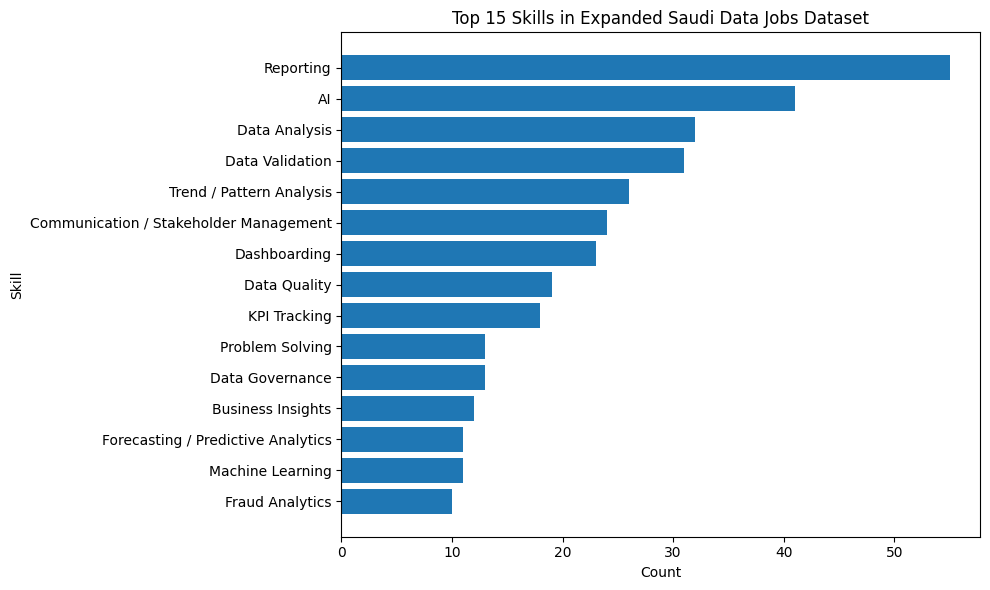

In [18]:
top_15_skills = top_skills.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_15_skills["skill"], top_15_skills["count"])
plt.xlabel("Count")
plt.ylabel("Skill")
plt.title("Top 15 Skills in Expanded Saudi Data Jobs Dataset")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "expanded_top_15_skills.png", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
city_counts = df["city_cleaned"].value_counts().reset_index()

city_counts.columns = ["city", "count"]

city_counts

,city,count
0,Riyadh,28
1,Jeddah,10
2,Not specified,5
3,Mahd Adh Dhahab,1
4,King Abdullah Economic City,1


In [20]:
city_counts.to_csv(TABLES_DIR / "expanded_city_counts.csv", index=False)

print("expanded_city_counts.csv saved.")

expanded_city_counts.csv saved.


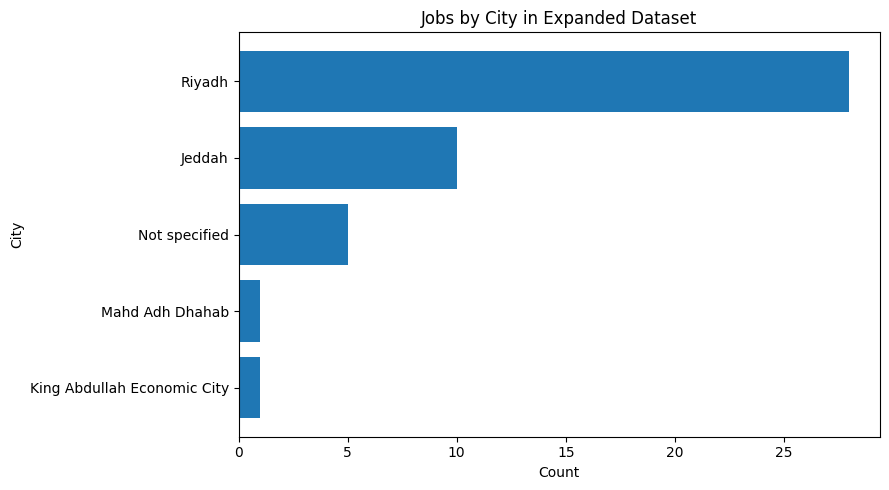

In [21]:
plt.figure(figsize=(9, 5))
plt.barh(city_counts["city"], city_counts["count"])
plt.xlabel("Count")
plt.ylabel("City")
plt.title("Jobs by City in Expanded Dataset")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "expanded_jobs_by_city.png", dpi=300, bbox_inches="tight")

plt.show()

In [22]:
role_counts = df["role_category"].value_counts().reset_index()

role_counts.columns = ["role_category", "count"]

role_counts

,role_category,count
0,AI,8
1,BI,6
2,Data Analysis,5
3,Data Science,5
4,Performance Analytics,5
5,Governance,4
6,Business / Financial Analytics,3
7,Fraud Analytics,3
8,Research Analytics,2
9,Product Analytics,1


In [23]:
role_counts.to_csv(TABLES_DIR / "expanded_role_category_counts.csv", index=False)

print("expanded_role_category_counts.csv saved.")

expanded_role_category_counts.csv saved.


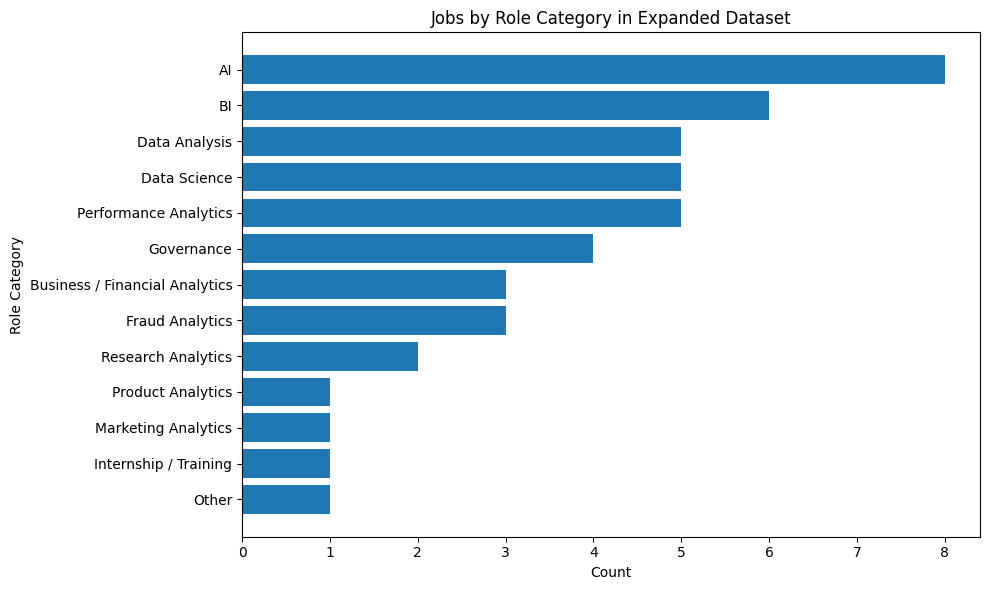

In [24]:
plt.figure(figsize=(10, 6))
plt.barh(role_counts["role_category"], role_counts["count"])
plt.xlabel("Count")
plt.ylabel("Role Category")
plt.title("Jobs by Role Category in Expanded Dataset")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "expanded_jobs_by_role_category.png", dpi=300, bbox_inches="tight")

plt.show()

In [25]:
experience_counts = df["experience_category"].value_counts().reset_index()

experience_counts.columns = ["experience_category", "count"]

experience_counts

,experience_category,count
0,Entry Level,18
1,Mid-Level,13
2,Not Specified,10
3,Internship,3
4,Senior,1


In [26]:
experience_counts.to_csv(TABLES_DIR / "expanded_experience_category_counts.csv", index=False)

print("expanded_experience_category_counts.csv saved.")

expanded_experience_category_counts.csv saved.


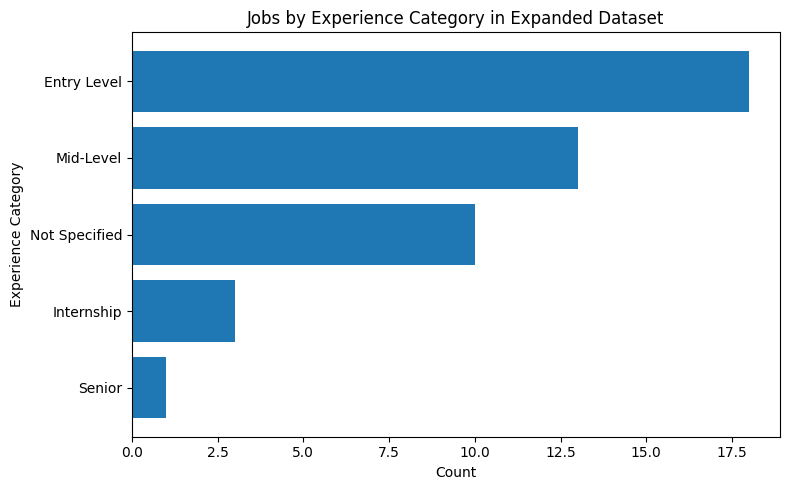

In [27]:
plt.figure(figsize=(8, 5))
plt.barh(experience_counts["experience_category"], experience_counts["count"])
plt.xlabel("Count")
plt.ylabel("Experience Category")
plt.title("Jobs by Experience Category in Expanded Dataset")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(FIGURES_DIR / "expanded_jobs_by_experience_category.png", dpi=300, bbox_inches="tight")

plt.show()

In [28]:
tools_by_role = pd.crosstab(
    tools_long["tool_normalized"],
    tools_long["role_category"]
)

top_10_tools_names = top_tools.head(10)["tool"].tolist()

tools_by_role_top10 = tools_by_role.loc[top_10_tools_names]

tools_by_role_top10

role_category,AI,BI,Business / Financial Analytics,Data Analysis,Data Science,Fraud Analytics,Governance,Internship / Training,Marketing Analytics,Other,Performance Analytics,Product Analytics,Research Analytics
tool_normalized,,,,,,,,,,,,,
SQL,2,4,1,2,4,1,3,0,1,0,3,1,2
Excel,0,5,2,4,1,1,0,0,1,0,6,0,1
Python,5,2,1,2,5,1,0,0,0,0,0,1,1
Power BI,2,6,1,2,3,0,1,0,0,0,2,0,1
Dashboards,1,3,2,2,0,2,1,0,0,0,3,0,0
Tableau,2,4,1,2,3,0,1,0,0,0,0,0,1
BI / Reporting Tools,0,4,2,1,0,1,3,0,0,0,2,0,1
TensorFlow,5,0,0,0,0,0,0,0,0,0,0,0,0
Machine Learning Tools,2,0,0,0,2,1,0,0,0,0,0,0,0


In [29]:
tools_by_role_top10.to_csv(TABLES_DIR / "expanded_tools_by_role_category.csv")

print("expanded_tools_by_role_category.csv saved.")

expanded_tools_by_role_category.csv saved.


In [30]:
skills_by_experience = pd.crosstab(
    skills_long["skill_normalized"],
    skills_long["experience_category"]
)

top_10_skills_names = top_skills.head(10)["skill"].tolist()

skills_by_experience_top10 = skills_by_experience.loc[top_10_skills_names]

skills_by_experience_top10

experience_category,Entry Level,Internship,Mid-Level,Not Specified,Senior
skill_normalized,,,,,
Reporting,22,0,16,16,1
AI,14,8,11,7,1
Data Analysis,13,2,9,8,0
Data Validation,16,0,9,6,0
Trend / Pattern Analysis,12,0,5,8,1
Communication / Stakeholder Management,6,1,7,9,1
Dashboarding,10,0,5,6,2
Data Quality,8,1,4,5,1
KPI Tracking,6,0,5,5,2


In [31]:
skills_by_experience_top10.to_csv(TABLES_DIR / "expanded_skills_by_experience_category.csv")

print("expanded_skills_by_experience_category.csv saved.")

expanded_skills_by_experience_category.csv saved.


In [32]:
print("Day 18 Expanded Dataset Analysis Summary")
print("----------------------------------------")

print("Total job postings:", df.shape[0])
print("Total columns:", df.shape[1])

print("\nTop 10 Tools:")
print(top_tools.head(10).to_string(index=False))

print("\nTop 10 Skills:")
print(top_skills.head(10).to_string(index=False))

print("\nJobs by City:")
print(city_counts.to_string(index=False))

print("\nJobs by Role Category:")
print(role_counts.to_string(index=False))

print("\nJobs by Experience Category:")
print(experience_counts.to_string(index=False))

Day 18 Expanded Dataset Analysis Summary
----------------------------------------
Total job postings: 45
Total columns: 15

Top 10 Tools:
                  tool  count
                   SQL     24
                 Excel     21
                Python     18
              Power BI     18
            Dashboards     14
               Tableau     14
  BI / Reporting Tools     14
            TensorFlow      5
Machine Learning Tools      5
               PyTorch      5

Top 10 Skills:
                                 skill  count
                             Reporting     55
                                    AI     41
                         Data Analysis     32
                       Data Validation     31
              Trend / Pattern Analysis     26
Communication / Stakeholder Management     24
                          Dashboarding     23
                          Data Quality     19
                          KPI Tracking     18
                       Problem Solving     13

Jobs by C

In [33]:
top_5_tools = top_tools.head(5)["tool"].tolist()
top_5_skills = top_skills.head(5)["skill"].tolist()

print("Main Takeaway")
print("-------------")
print("After expanding the dataset to 45 Saudi data-related job postings, the most mentioned tools are:")
print(", ".join(top_5_tools))

print("\nThe most mentioned skills are:")
print(", ".join(top_5_skills))

print("\nThe expanded dataset gives a more reliable view of tool and skill demand compared with the earlier 25-posting sample.")

Main Takeaway
-------------
After expanding the dataset to 45 Saudi data-related job postings, the most mentioned tools are:
SQL, Excel, Python, Power BI, Dashboards

The most mentioned skills are:
Reporting, AI, Data Analysis, Data Validation, Trend / Pattern Analysis

The expanded dataset gives a more reliable view of tool and skill demand compared with the earlier 25-posting sample.


In [34]:
print("Saved tables:")
for file in TABLES_DIR.iterdir():
    print(file)

print("\nSaved figures:")
for file in FIGURES_DIR.iterdir():
    print(file)

Saved tables:
tables/expanded_top_skills.csv
tables/expanded_experience_category_counts.csv
tables/expanded_role_category_counts.csv
tables/expanded_tools_by_role_category.csv
tables/expanded_city_counts.csv
tables/expanded_skills_by_experience_category.csv
tables/expanded_top_tools.csv

Saved figures:
figures/expanded_jobs_by_city.png
figures/expanded_jobs_by_experience_category.png
figures/expanded_jobs_by_role_category.png
figures/expanded_top_15_tools.png
figures/expanded_top_15_skills.png


## Day 18 Summary

In this notebook, I re-ran the main analysis using the expanded cleaned dataset.

The dataset now contains 45 Saudi data-related job postings.

Completed analysis:
- Checked dataset quality
- Re-analyzed tools
- Re-analyzed skills
- Re-analyzed city distribution
- Re-analyzed role category distribution
- Re-analyzed experience category distribution
- Created updated analysis tables
- Saved updated charts
- Continued Kaggle Intro to Machine Learning with Model Validation

Main output:
- Updated top tools table
- Updated top skills table
- Updated city distribution
- Updated role category distribution
- Updated experience category distribution
- Updated charts for the expanded dataset

The expanded analysis helps make the project findings more reliable because the dataset is larger than the initial 25-posting sample.